In [65]:
import importlib as il
import numpy as np
import more_itertools as mit

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl

%matplotlib inline
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

What we want to do here:
1. Find an LP optimum for some problem.
2. Back away from that optimum into the interior sqrt(n)/2 distance.
3. Find the eigenvectors for Dikin's H at that point.
4. Round those to be integer values.
5. Run the LLL reduction on that result.
6. Make that be unimodular if it's not.
7. Transform the original problem and run the MIP solver for it.

In [45]:
def retreat_from_optimum_via_average_vector(V: np.ndarray, x: np.ndarray, target_distance):
    """Retreat from the optimum by moving in the direction of the average vector."""
    # this isn't perfect at the moment in that we should normalize the columns of V first.
    # that way each vector would contribute equally to the average.
    # however, some columns are zero-length, and we would have to handle that case.
    
    # normalize the columns first so that they all contribute equally:
    V /= np.linalg.norm(V, axis=0)

    avg = np.mean(V, axis=1)
    nrm = np.linalg.norm(avg) + 1e-5
    return x - avg * target_distance / nrm

def find_corner(relaxed: gp.Model, int_vars, int_var_idx):
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    variables = relaxed.getVars()
    constraints = relaxed.getConstrs()
    for col, j in enumerate(col_to_var_idx):
        if j < len(variables):
            # print("Var INFO:", variables[j].VarName, "VBasis", variables[j].VBasis, "LB", variables[j].LB, "UB", variables[j].UB)
            if variables[j].VBasis == -2:
                # tableau[:, col] = variables[j].UB - tableau[:, col]
                tableau[:, col] = -tableau[:, col]
                print("   VBasis at -2 for", variables[j].VarName, variables[j].UB)
    #         if variables[j].VBasis == -1:  # not sure what to do with VBasis=-3
    #             tableau[:, col] = -tableau[:, col]  # variables[j].LB
    #             if variables[j].LB != 0.0:
    #                 print("Warning: LB is nonzero for variable", variables[j].VarName, "LB", variables[j].LB, "UB", variables[j].UB)
        else:
            constraint = constraints[j - len(variables)]
    #         # this might not be right: scip has status and tests for A_i*x being at lower or upper bound
    #         # if np.isclose(constraint.Slack, 0.0, atol=tol):
    #         #     tableau[:, col] = -tableau[:, col]
            if constraint.Sense == '>':  # Achterberg said lt and lte are standard; should just need to flip gt
                tableau[:, col] = -tableau[:, col]
                print("   GTE Constraint found for", constraint.ConstrName)

    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in int_var_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop) # update basis to match tableau

    # we want all the integer variables in order, assuming x, y as the first two.
    # however, some integer variables may be columns in the tableau, which is problematic.

    basis, tableau = mit.sort_together([basis, tableau], key_list=[0]) #, key=int_var_idx.get)
    tableau = np.array(tableau)

    sv = [int_vars[int_var_idx[b]].X for b in basis]
    return tableau, np.array(sv)

def make_primal_dual_values(mdl: gp.Model):
    """Extract primal and dual values from the model."""
    primal = np.array([v.X for v in mdl.getVars()])
    dual_cons = np.array([c.Pi for c in mdl.getConstrs()])
    # dual_vars = np.array([v.RC for v in mdl.getVars()])
    return primal, dual_cons

def get_A_b_c_l_u(mdl: gp.Model):
    mdl.update()
    A = mdl.getA()
    b = np.array(mdl.getAttr("RHS")).reshape(-1, 1)
    c = np.array(mdl.getAttr("Obj"))
    l = np.array(mdl.getAttr("LB"))
    u = np.array(mdl.getAttr("UB"))
    return A, b, c, l , u



   Relaxed 2 variables on 2D from bottom
Running: 2D from bottom
   Negated 0 constraints on 2D from bottom
   Retreat to: [1.15628105 1.66739216]
   Relaxed 2 variables on 2D no easy cut from bottom
Running: 2D no easy cut from bottom
   Negated 0 constraints on 2D no easy cut from bottom
   Retreat to: [3.04984591 2.35736467]
   Relaxed 2 variables on 2D from top
Running: 2D from top
   Negated 2 constraints on 2D from top
   Retreat to: [1.28816339 2.9992745 ]
   Relaxed 2 variables on 2D from bottom (upper bounded x)
Running: 2D from bottom (upper bounded x)
   Negated 0 constraints on 2D from bottom (upper bounded x)
   Retreat to: [0.57573593 1.08684704]
   Relaxed 2 variables on 2D from bottom (steep, y<=2)
Running: 2D from bottom (steep, y<=2)
   Negated 0 constraints on 2D from bottom (steep, y<=2)
   Retreat to: [1.25      0.4732634]
   Relaxed 2 variables on 2D slanted
Running: 2D slanted
   Negated 0 constraints on 2D slanted
   Retreat to: [2.20744268 1.05744268]
   Relaxe

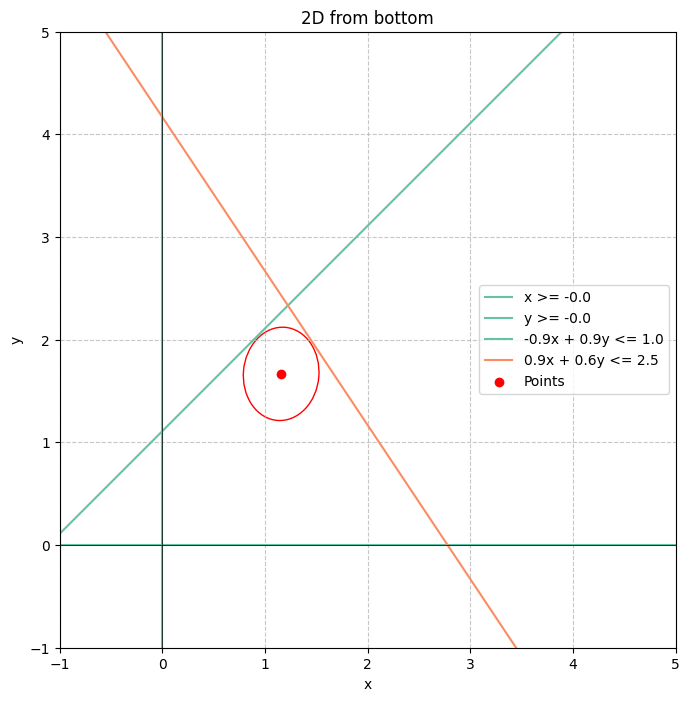

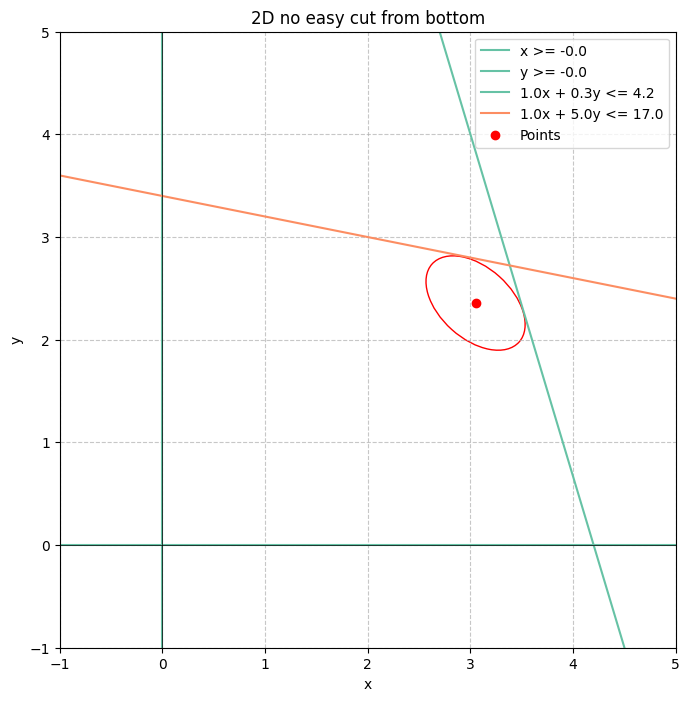

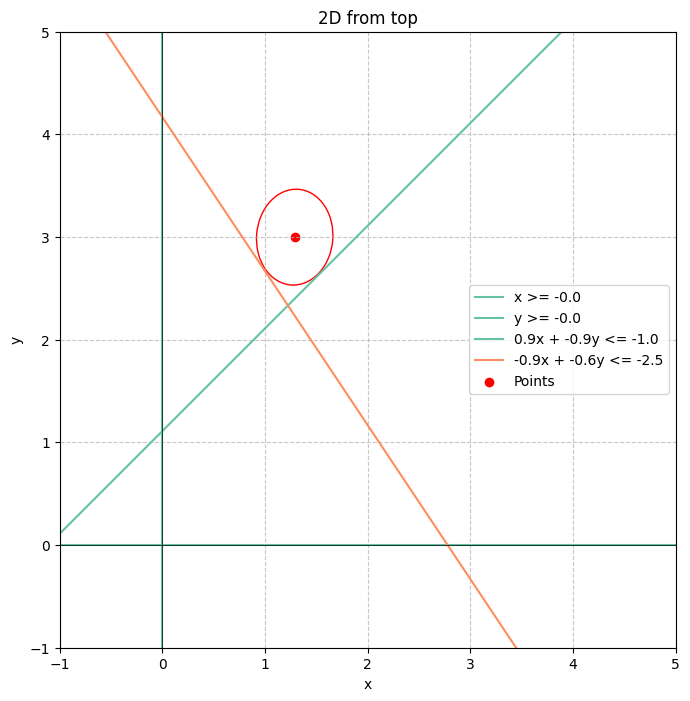

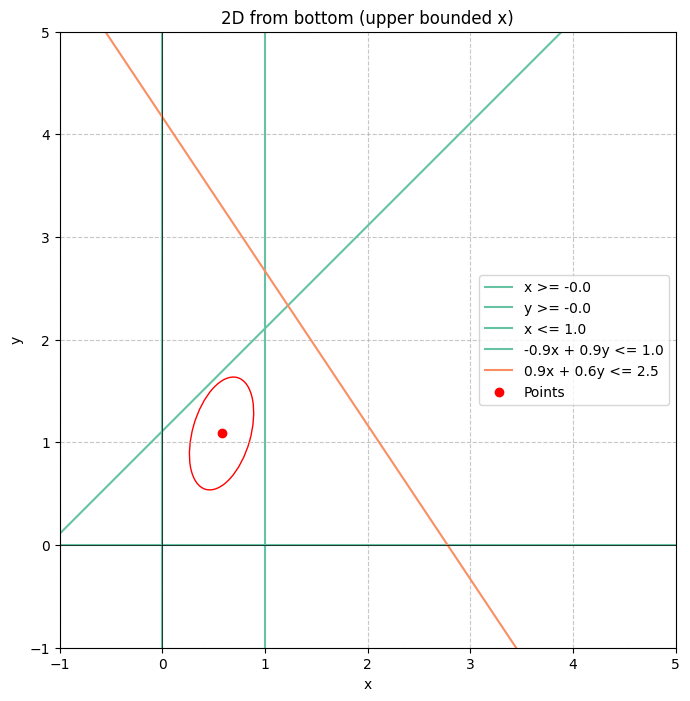

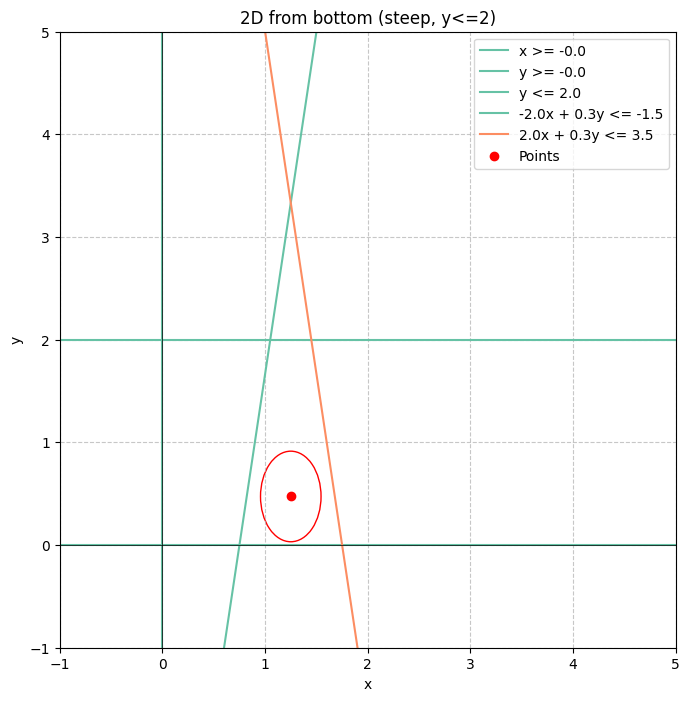

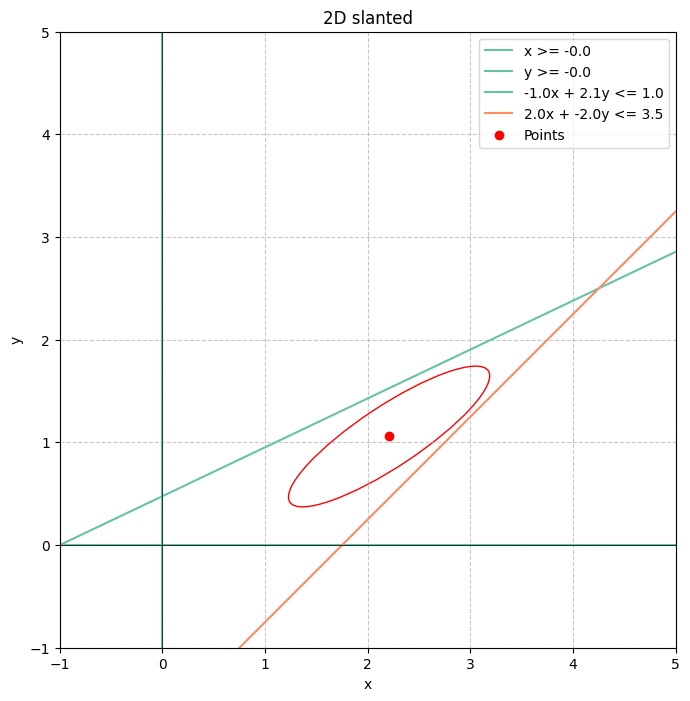

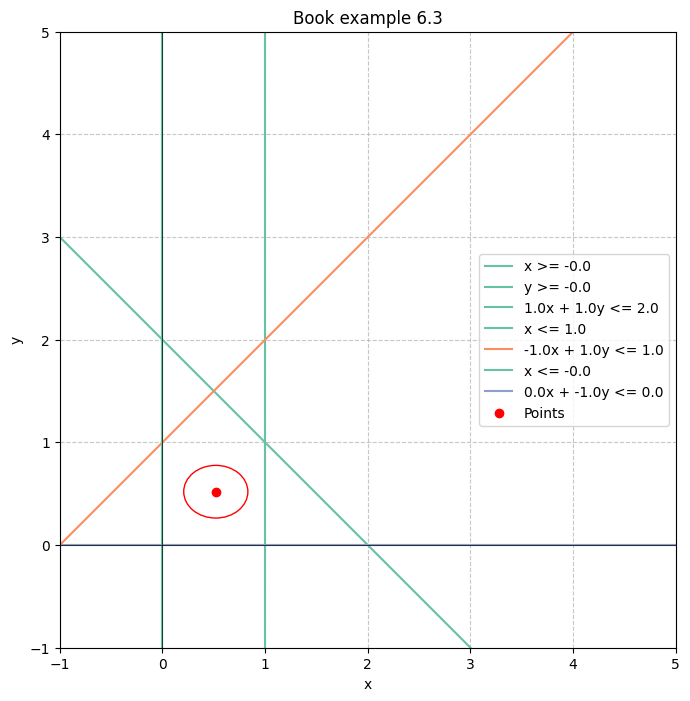

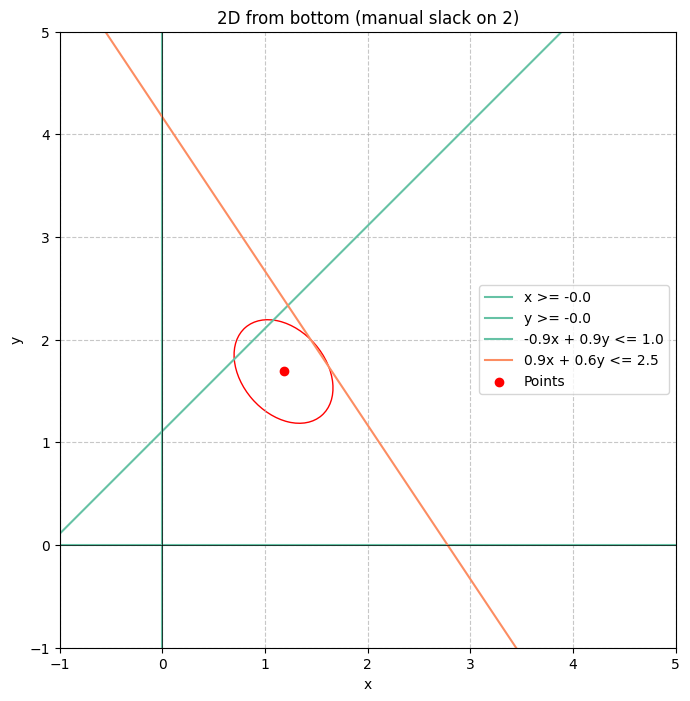

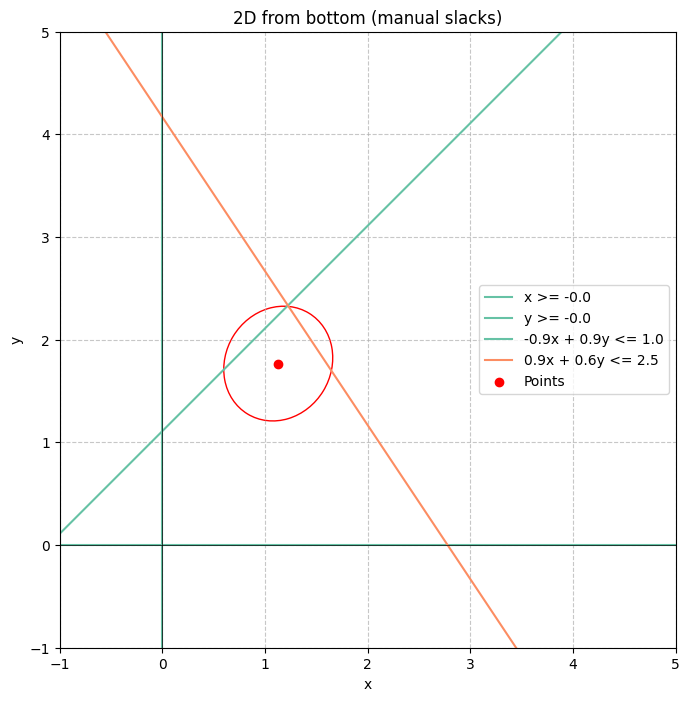

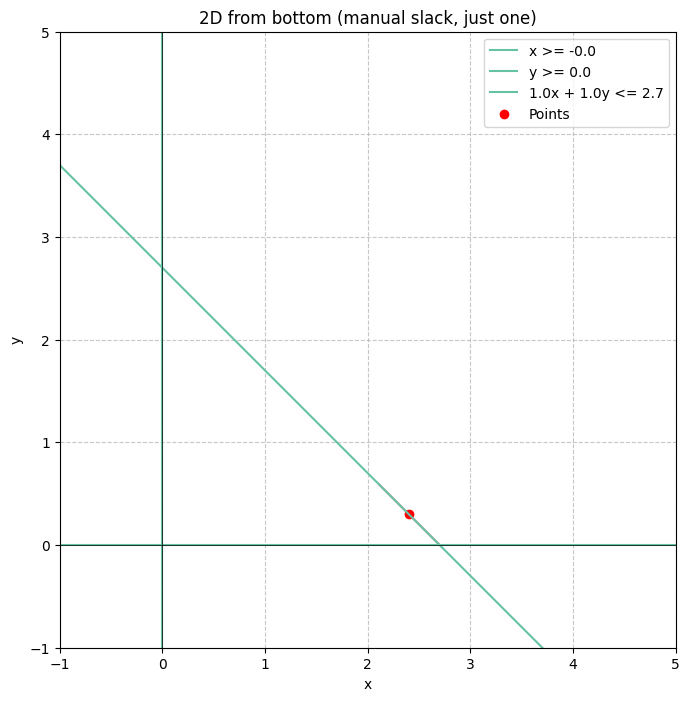

In [91]:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

def shrink(mdl: gp.Model, diagonal_distance, percent_of_diagonal):
    assert diagonal_distance > 0.0 and percent_of_diagonal > 0.0 and percent_of_diagonal < 0.5
    mdl.update()
    result = mdl.copy()
    if result.NumIntVars > 0:
        _, _ = gu.relax_int_or_bin_to_continuous(result)
    result.update()
    distance = diagonal_distance * percent_of_diagonal
    for v in result.getVars():
        if v.UB - v.LB < distance * 2.0:
            gap = (v.UB - v.LB) * percent_of_diagonal
            v.LB += gap
            v.UB -= gap
        else:
            if v.LB > -gp.GRB.INFINITY:
                v.LB += distance
            if v.UB < gp.GRB.INFINITY:
                v.UB -= distance
    for c in result.getConstrs():
        lhs = result.getRow(c)
        coeffs = np.array([lhs.getCoeff(i) for i in range(lhs.size())])
        if c.Sense == '<':
            c.RHS -= distance * np.linalg.norm(coeffs)
        elif c.Sense == '>':
            c.RHS += distance * np.linalg.norm(coeffs)
    result.update()
    return result

instances = el.get_instances(env)
for instance in list(instances.values()):
    model = instance.as_gurobi_model()
    model.update()
    niv = model.NumIntVars
    _, _ = gu.relax_int_or_bin_to_continuous(model)
    model.update()
    # model.optimize()
    # x = np.array([v.X for v in model.getVars()])
    print("Running:", model.ModelName)
    copy = shrink(model, np.sqrt(niv), 0.3)
    copy.optimize()
    x2 = np.array([v.X for v in copy.getVars()])
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    # x, y = make_primal_dual_values(model)
    gu.standardize_gt_to_lt(model)
    A, b, c, l, u = get_A_b_c_l_u(model)
    # x2, its = du.least_squares_interior(A, b, x, l, u, d=np.sqrt(int_vars.size) * 0.4, infinity=gp.GRB.INFINITY)
    # x2, its = du.reverse_interior_point_gpt2(A, b, c, l, u, x, y, target_distance=np.sqrt(int_vars.size) * 0.4,
    #                                          infinity=10, is_maximizing=model.ModelSense == gp.GRB.MAXIMIZE)
    print("   Retreat to:", x2)
    fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, points=[x2[:2]])
    A, b = du.append_bounds_to_matrix(A, b, l, u, infinity=gp.GRB.INFINITY)
    du.plot_ellipse(A, b, x2, fig=fig)

    # gu.standardize_gt_to_lt(copy)
    # A, b, c, l, u = get_A_b_c_l_u(copy)
    # fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, points=[x2[:2]], fig=fig)


    # could assert x2 is feasible




In [12]:
il.reload(du)
# test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
test = np.array([[.1, -1, .3], [1, 0, 5], [1, 2, 6]])
# test = np.array([[1, 0, 5], [1, -1, 3], [1, 2, 6]])

du.CLLL(test) 

(array([[-0.6, -0.2, -0.3],
        [ 0. ,  0. ,  1. ],
        [ 0. ,  1. ,  0. ]]),
 8)

In [13]:
# make it be round:

il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

instances = el.get_instances(env)
# instances = jl.get_instances()
for instance in list(instances.values())[0:3]:
    # model = instance.as_gurobi_balas_model(use_big_m=True, env=env)
    model = instance.as_gurobi_model()
    print("Running:", model.ModelName)
    gu.standardize_gt_to_lt(model)
    int_vars, int_var_idx = gu.relax_int_or_bin_to_continuous(model)
    model.optimize()
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    x, y = make_primal_dual_values(model)
    A, b, y2 = get_A_b_with_bounds_lte(model)
    y = np.hstack((y, y2))
    x2, its = du.reverse_interior_point_gpt(A, b, x, y, target_distance=np.sqrt(int_vars.size) * 0.4)
    print("   Optimum:", x, "Retreat to:", x2, "Iters:", its)
    assert not np.any(np.isnan(x2))
    # drop all columns in A not in int_var_idx: talk to Hildebrand on this
    # A = A[:, list(int_var_idx.keys())]
    H, H2 = du.compute_H(A, b, x2)
    H2 = np.round(H2 * 1000)
    H2a, U2a = du.CLLL(H2)
    print("Determinant:", np.linalg.det(U2a))

    # update or copy the model with:
    # 1. objective becomes c.T@Uy
    # 2. constraints become A@Uy <= b
    # 3. x >= 0 becomes U@y >= 0 (only if U has any negative entries)
    # update_objective(model, U, int_var_idx)
    # update_constraints(model, U, A, b)
    # update_bounds(model, U, int_var_idx)

    # fig = pu.plot_constraints_lte(model.ModelName, A, b, points=[x[:2], x2[:2]])
    # du.plot_ellipse(A, b, x2, fig=fig)


Running: 2D from bottom
   Negated 0 constraints on 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Optimum: [1.22222222 2.33333333] Retreat to: [1.22222222 1.76764791] Iters: 5
Vecs:
 [[ 0.13862039 -0.28841704]
 [-0.39517639 -0.10117123]]
Determinant: 0.1279999999999999
Basis is already reduced.
Running: 2D no easy cut from bottom
   Negated 0 constraints on 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom
   Optimum: [3.38297872 2.72340426] Retreat to: [2.98297872 2.32340426] Iters: 4
Vecs:
 [[-0.51554149  0.25239934]
 [ 0.42156811  0.30866265]]
Determinant: 0.2655319148936174
Basis is already reduced.
Running: 2D from top
   Negated 2 constraints on 2D from top
   Relaxed 2 variables on 2D from top
   Optimum: [1.22222222 2.33333333] Retreat to: [1.22222222 2.89901876] Iters: 5
Vecs:
 [[ 0.13862039 -0.28841704]
 [-0.39517639 -0.10117123]]
Determinant: 0.12800000000000017
Basis is already reduced.
